In [2]:
import kagglehub
path = kagglehub.dataset_download("spscientist/students-performance-in-exams")

Using Colab cache for faster access to the 'students-performance-in-exams' dataset.


In [4]:
import pandas as pd

data = pd.read_csv(r'/kaggle/input/students-performance-in-exams/StudentsPerformance.csv')
data

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [5]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
plt.switch_backend('Agg')

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder

# Configure inline plotting
%matplotlib inline

# Set visual styles
sns.set(style="whitegrid")

In [6]:
if data.empty:
    raise ValueError('The input dataset is empty. Please check the file and its path.')

if set(data['test preparation course'].str.lower().unique()) <= {"completed", "none"}:
    data['test preparation course'] = data['test preparation course'].str.lower().map({'completed': 1, 'none': 0})
else:
    le = LabelEncoder()
    data['test preparation course'] = le.fit_transform(data['test preparation course'])

df = pd.get_dummies(data, drop_first=True)

print("\nData after encoding:")
display(df.head())


Data after encoding:


,test preparation course,math score,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard
0,0,72,72,74,False,True,False,False,False,True,False,False,False,False,True
1,1,69,90,88,False,False,True,False,False,False,False,False,True,False,True
2,0,90,95,93,False,True,False,False,False,False,False,True,False,False,True
3,0,47,57,44,True,False,False,False,False,False,False,False,False,False,False
4,0,76,78,75,True,False,True,False,False,False,False,False,True,False,True


Accuracy Score: 0.7300


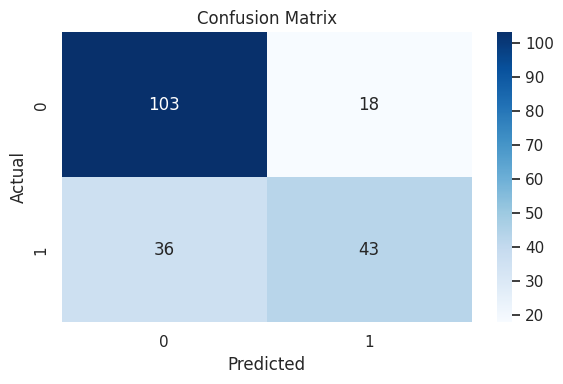

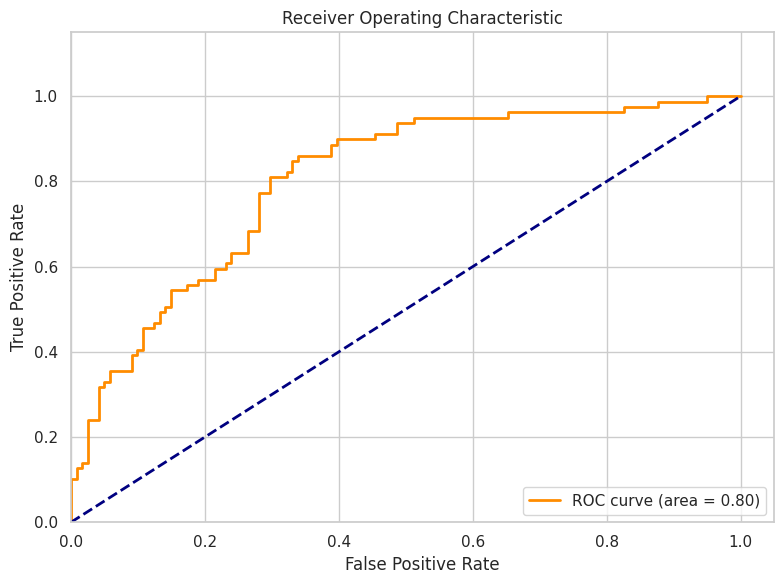

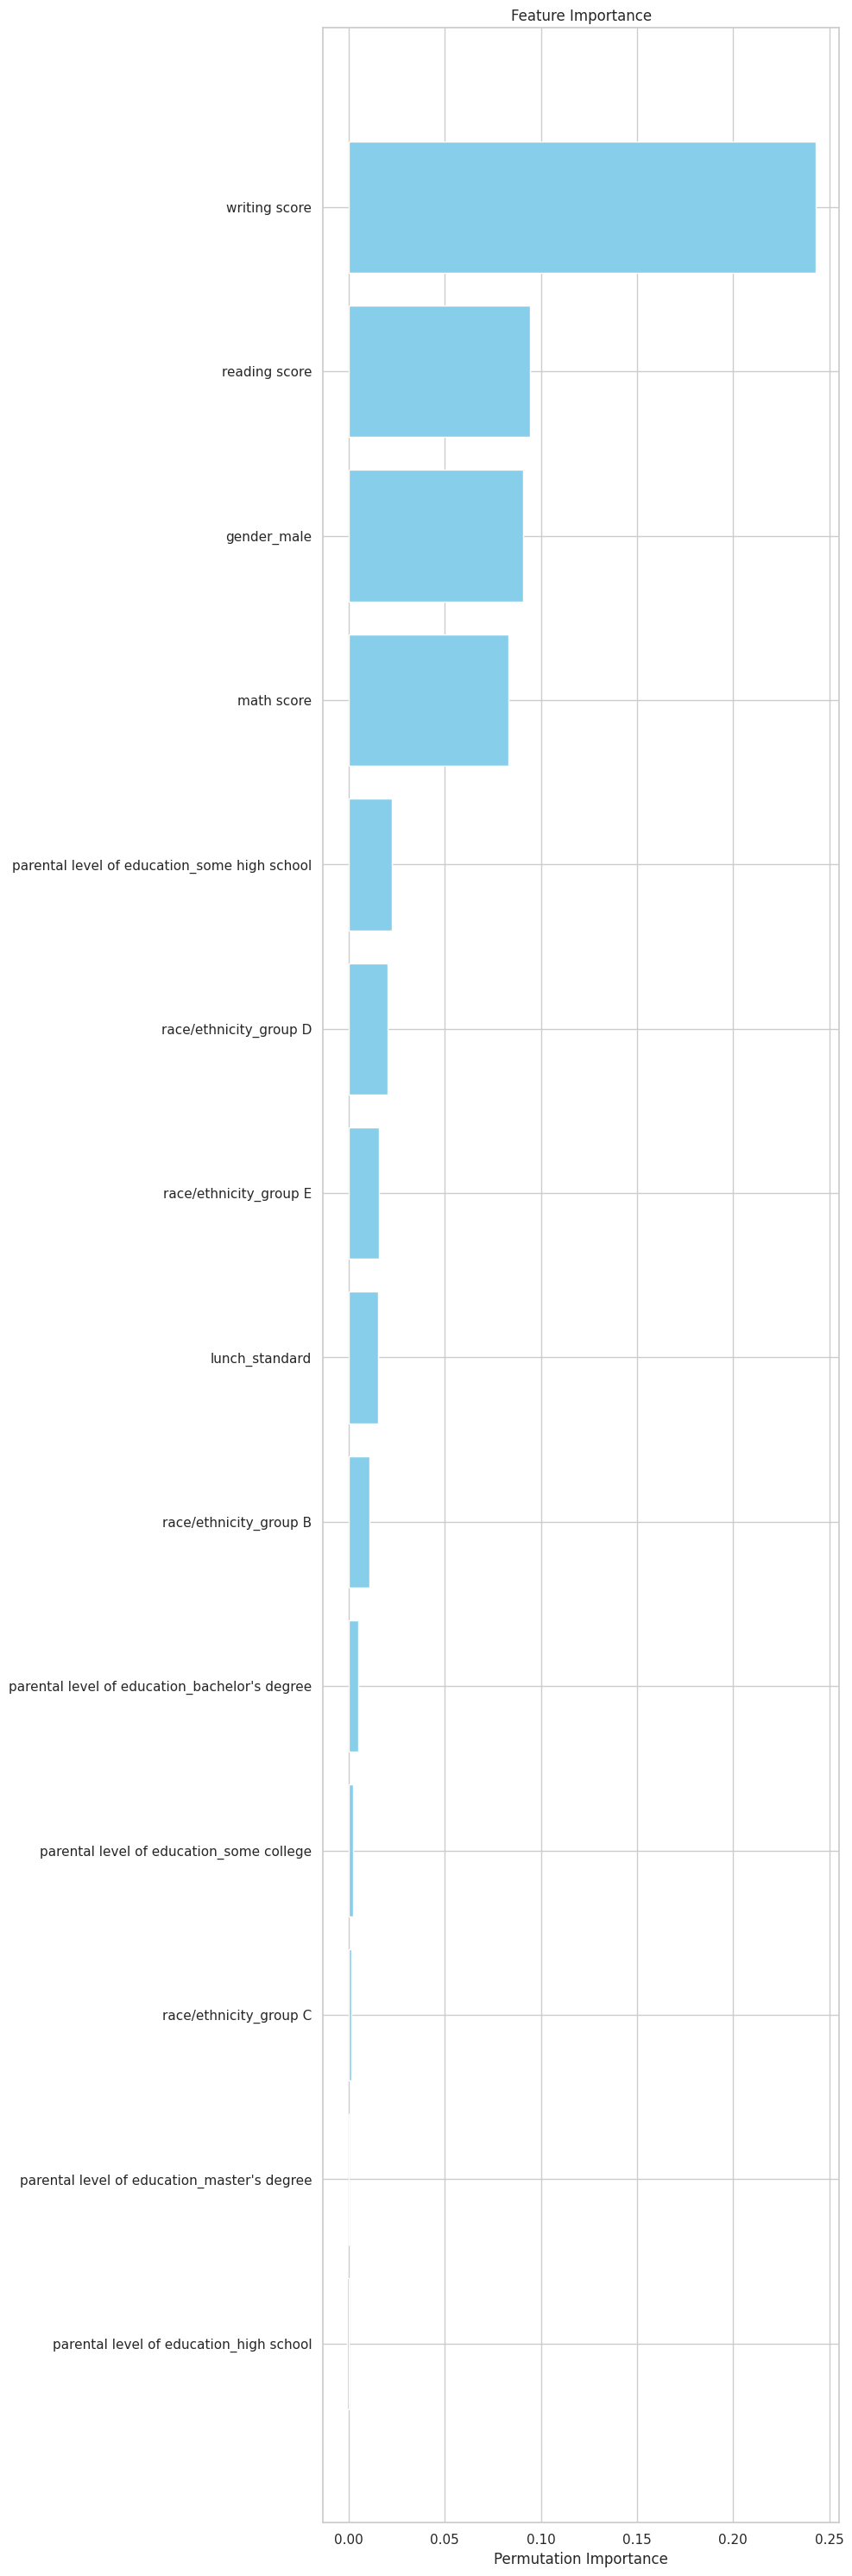

In [9]:
df.dropna(inplace=True)

# 2. Separate features (X) and target (y)
X = df.drop('test preparation course', axis=1)
y = df['test preparation course']

# 3. Check if the feature matrix is empty after dropping NaNs
if X.shape[0] == 0:
    raise ValueError('The feature matrix is empty after dropping NaNs. Check your data for extensive missing values.')

# 4. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Check if the training set is empty after splitting
if X_train.shape[0] == 0:
    raise ValueError('Training set is empty after splitting. Adjust the test_size or check the input data.')

# 6. Train the Logistic Regression model
model = LogisticRegression(max_iter=10000, random_state=42)
model.fit(X_train, y_train)

# 7. Make predictions
y_pred = model.predict(X_test)

# 8. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy Score: {accuracy:.4f}')

# 9. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# 10. ROC Curve (only if the target variable has binary labels)
if set(y_test.unique()) <= {0, 1}:
    y_probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.05])
    plt.ylim([0.0, 1.15])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
else:
    print('ROC Curve requires binary labels. Please ensure that the target variable is encoded correctly.')

# 11. Permutation Importance
result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, scoring='accuracy')
importance_df = pd.DataFrame({'feature': X_test.columns, 'importance': result.importances_mean})
importance_df = importance_df.sort_values(by='importance', ascending=True)

plt.figure(figsize=(10, 30))
plt.barh(importance_df['feature'], importance_df['importance'], color='skyblue')
plt.xlabel('Permutation Importance')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()